### Clustering 
For clustering I am using GMM (Gaussian Mixture Model). 

<b>Reasons for choosing GMM:</b>
- Hard clustering is not accepted for this assignment so that eliminates k-means.
- GMM models the data as a mixture of probabiliy distributions.
- So we can actually see the probability of an article to belong to a particular cluster rather than labelling that data with 1 or some clusters.
- GMM is probabilistic, stable and the standard ML approach. 
- GMM is not computationally very expensive so it makes the overall thing light weight.

Now, there are some problems with GMM. GMM does not perform very well in high dimension vectors. The embeddings generated have a size of 384 each. So this is quite high for GMM and GMM will likely not perform very well in this high dimension. 

<b>Dimensionality Reduction:</b>
- I have used UMAP (Uniform Manifold Approximation and Projection) for reducing the dimensions to 10.
- This will reduce the dimentions as well as preserve the information to high extent for the GMM model to cluster. 
- UMAP is non-linear so it can also capture the local topology of the data. 

Now, that the dimensions are reduced, the criterion in GMM can be set to `full` instead of `diag` so we can capture non-linear relations among data instead of only diagonal.

#### Determining the number of clusters.

As per the assignment, no. of clusters cannot be something random based on intuition. There has to be a mathematical justification behing the no. of clusters. 

For choosing the number of clusters I am using the BIC (Bayesian Information Criterion) - this computers the log likelihood among the clusters. The lesser the likelihood, the more distinct the clusters are and better the results. 

Low BIC means the subject of the clusters are well apart. 




In [4]:
import numpy as np
from sklearn.mixture import GaussianMixture
import umap
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture

embeddings = np.load("embeddings.npy")

In [5]:
def find_optimal_clusters_with_umap(embeddings, target_dims=10):
    """
    Reduces dimensionality using UMAP
    Runs BIC analysis to find the best K for GMM
    """
    
    # n_neighbors: 30 is a good balance for global vs local structure
    # min_dist: low value (0.0) helps with clustering density
    reducer = umap.UMAP(
        n_neighbors=30,
        min_dist=0.0,
        n_components=target_dims, 
        random_state=42
    )
    
    reduced_embeddings = reducer.fit_transform(embeddings)
    print(f"Reduced embeddings shape: {reduced_embeddings.shape}")

    bic_scores = []
    cluster_range = range(5, 500, 20) 

    for k in cluster_range:
        # using 'full' covariance because the dimentions are reduced to 10
        # GMM can now afford to model the full elliptical shape
        gmm = GaussianMixture(
            n_components=k,
            covariance_type="full", 
            random_state=42
        )
        gmm.fit(reduced_embeddings)
        bic = gmm.bic(reduced_embeddings)
        bic_scores.append(bic)
        print(f"k={k}, BIC={bic:.2f}")

    return cluster_range, bic_scores, reduced_embeddings


In [11]:

clusters, bics, reduced_data = find_optimal_clusters_with_umap(embeddings)

/media/ashmit/External Storage/VIT/Academics/Sixth Semester/trademarkia/semantic_search/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Reduced embeddings shape: (19997, 10)
k=5, BIC=-133294.24
k=25, BIC=-477575.33
k=45, BIC=-572564.44
k=65, BIC=-629609.12
k=85, BIC=-667845.24
k=105, BIC=-697362.65
k=125, BIC=-712338.94
k=145, BIC=-729799.45
k=165, BIC=-743292.80
k=185, BIC=-753225.37
k=205, BIC=-756326.84
k=225, BIC=-760477.50
k=245, BIC=-763625.95
k=265, BIC=-761866.78
k=285, BIC=-761158.39
k=305, BIC=-759284.56
k=325, BIC=-755210.52
k=345, BIC=-751969.02
k=365, BIC=-748766.27
k=385, BIC=-744252.53
k=405, BIC=-740719.79
k=425, BIC=-734097.37
k=445, BIC=-728950.26
k=465, BIC=-723455.76
k=485, BIC=-717802.29


[]

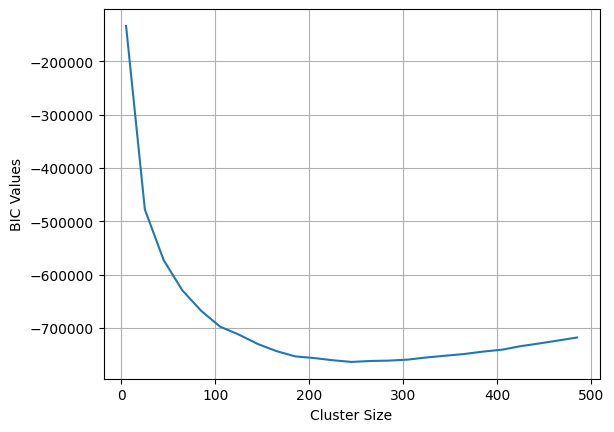

In [18]:
plt.plot(clusters, bics)
plt.grid(True)
plt.xlabel("Cluster Size")
plt.ylabel("BIC Values")
plt.plot()

### Finalizing no. of clusters from mathematical evidence

From the values of BIC (Bayesian Information Criterion) and the plotted graph it is evident that the global minimum is hit when the number of clusters is around 245. 


But for a dataset containing 20,000 samples 245 clusters is a lot. If so many clusters are present the search will loose generalization and have only specificity. 


One more observation from the graph is that the highest dip happens from 0 to 100.
And from numeric data we can see that the highest dip is from 5 to 25. 


So to maintain the genaralization aspect of the dataset during searching I choose 25 as the number of cluster. 


<b>Pros:</b>
- The search will be general and not very specific. 
- Overfitting will not be a problem. 
- If no. of clusters is set to such a high number, then for each news article there will be only one cluster which will have probability of nearly 1 and all the other clusters will be having very less probablity. 
- So, there will be very less outliers.
- Basically, high cluster count will make the data labelled instead of making it clustered.



<b>Cons:</b>
- larger number of clusters would have made the search and cache hit faster 


In [6]:
def train_gmm(embeddings, n_clusters):

    gmm = GaussianMixture(
        n_components=n_clusters,
        covariance_type="diag",
        random_state=42
    )

    gmm.fit(embeddings)

    return gmm

In [7]:
import pandas as pd
import joblib

df = pd.read_csv("vectorized_data.csv")

reducer = umap.UMAP(
    n_neighbors=30,
    min_dist=0.0,
    n_components=10, 
    random_state=42
)

reduced_embeddings = reducer.fit_transform(embeddings)
print(f"Reduced embeddings shape: {reduced_embeddings.shape}")

gmm = train_gmm(reduced_embeddings, 25)
joblib.dump(gmm, "gmm_model.pkl")
joblib.dump(reducer, "umap_reducer.pkl")

/media/ashmit/External Storage/VIT/Academics/Sixth Semester/trademarkia/semantic_search/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Reduced embeddings shape: (19997, 10)


['umap_reducer.pkl']

In [9]:
cluster_probs = gmm.predict_proba(reduced_embeddings)

#calculate the cluster which has the highest probability for that particular article
dominant_cluster = cluster_probs.argmax(axis=1) 

df["cluster_probs"] = cluster_probs.tolist()
df["dominant_cluster"] = dominant_cluster
df.to_csv("clustered_dataset.csv", index=False)


In [12]:
df["dominant_cluster"].value_counts()

dominant_cluster
21    1565
10    1256
6     1170
9     1170
19    1123
8     1038
17    1032
2     1022
22    1013
13     944
16     923
14     919
4      879
5      863
20     720
11     673
3      669
0      592
15     477
18     476
12     402
1      354
23     308
24     240
7      169
Name: count, dtype: int64